In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

base   = r'C:\Users\chant\ecommerce-analytics\data\raw'
out    = r'C:\Users\chant\ecommerce-analytics\data\processed'
models = r'C:\Users\chant\ecommerce-analytics\models'

orders   = pd.read_csv(os.path.join(base, 'orders.csv'), parse_dates=['order_date'])
products = pd.read_csv(os.path.join(base, 'products.csv'))
customers= pd.read_csv(os.path.join(base, 'customers.csv'))
print("Loaded")

Loaded


In [2]:
# merge all needed tables
df = orders.merge(products[['product_id','category','price']], on='product_id', how='left')
df = df.merge(customers[['customer_id','household_size']], on='customer_id', how='left')

# features for pricing model
df['effective_price']  = df['final_price'] / df['quantity'].clip(lower=1)
df['discount_pct']     = df['discount_applied'] / (df['base_price'] + 1)
df['has_hidden_fee']   = (df['hidden_fee'] > 0).astype(int)
df['is_large_family']  = (df['household_size'] >= 5).astype(int)
df['log_price']        = np.log1p(df['effective_price'])
df['log_qty']          = np.log1p(df['quantity'])
df['order_month']      = df['order_date'].dt.month

le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'].fillna('Unknown'))

features = ['log_price','discount_pct','has_hidden_fee',
            'is_large_family','category_enc','order_month']
target   = 'log_qty'

df_model = df[features + [target]].dropna()
print(f"Pricing model dataset: {df_model.shape}")
print(df_model.describe().round(2))

Pricing model dataset: (9846, 7)
       log_price  discount_pct  has_hidden_fee  is_large_family  category_enc  \
count    9846.00       9846.00         9846.00          9846.00       9846.00   
mean        4.85          0.16            0.51             0.43          2.14   
std         1.19          0.24            0.50             0.50          1.30   
min        -5.70          0.00            0.00             0.00          0.00   
25%         4.12          0.00            0.00             0.00          1.00   
50%         4.87          0.06            1.00             0.00          2.00   
75%         5.62          0.21            1.00             1.00          3.00   
max         8.51          1.99            1.00             1.00          4.00   

       order_month  log_qty  
count      9846.00  9846.00  
mean          6.61     1.69  
std           3.47     0.50  
min           1.00     0.69  
25%           4.00     1.39  
50%           7.00     1.79  
75%          10.00     2.08

In [3]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"\nCoefficients:")
for feat, coef in zip(features, reg.coef_):
    print(f"  {feat:<22}: {coef:+.4f}")

R² Score : 0.4335
MAE      : 0.3093

Coefficients:
  log_price             : -0.3488
  discount_pct          : -0.9690
  has_hidden_fee        : +0.1056
  is_large_family       : -0.0096
  category_enc          : +0.0008
  order_month           : +0.0000


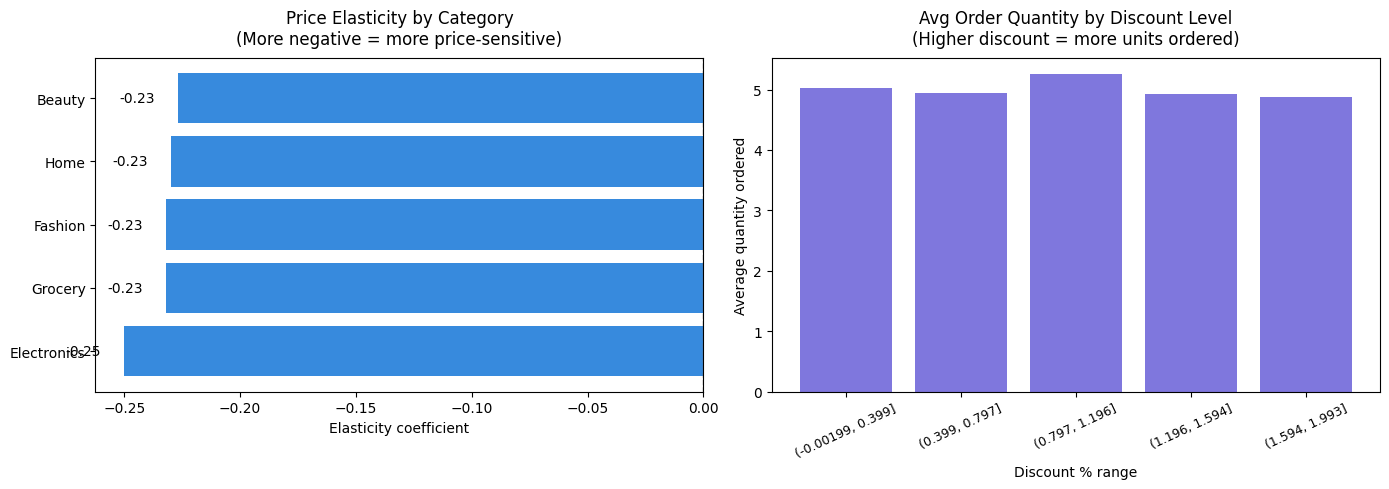

Model 2 saved

Elasticity summary:
Electronics   -0.250
Grocery       -0.232
Fashion       -0.232
Home          -0.230
Beauty        -0.227

Most price-sensitive : Electronics (-0.250)
Least price-sensitive: Beauty (-0.227)


In [5]:
# Cell 4 — elasticity by category & discount threshold chart

# compute elasticity per category
elasticity = {}
for cat in df['category'].dropna().unique():
    cat_df = df[df['category']==cat][['log_price','log_qty']].dropna()
    if len(cat_df) > 30:
        m = LinearRegression().fit(cat_df[['log_price']], cat_df['log_qty'])
        elasticity[cat] = round(m.coef_[0], 3)

elast_df = pd.Series(elasticity).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- elasticity bar ---
colors = ['#D85A30' if v < -0.5 else '#378ADD' for v in elast_df.values]
axes[0].barh(elast_df.index, elast_df.values, color=colors, edgecolor='none')
axes[0].axvline(0, color='gray', lw=1, linestyle='--')
axes[0].set_title('Price Elasticity by Category\n(More negative = more price-sensitive)',
                   fontsize=12, pad=10)
axes[0].set_xlabel('Elasticity coefficient')
for i, (cat, val) in enumerate(elast_df.items()):
    axes[0].text(val + 0.01 if val >= 0 else val - 0.01, i,
                 f'{val:+.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)

# --- discount vs avg quantity ---
disc_bins = pd.cut(df['discount_pct'], bins=5)
disc_qty  = df.groupby(disc_bins, observed=True)['quantity'].mean()
axes[1].bar(range(len(disc_qty)), disc_qty.values, color='#7F77DD', edgecolor='none')
axes[1].set_xticks(range(len(disc_qty)))
axes[1].set_xticklabels([str(i) for i in disc_qty.index], rotation=25, fontsize=9)
axes[1].set_title('Avg Order Quantity by Discount Level\n(Higher discount = more units ordered)',
                   fontsize=12, pad=10)
axes[1].set_ylabel('Average quantity ordered')
axes[1].set_xlabel('Discount % range')

plt.tight_layout()
plt.savefig(os.path.join(out, 'model2_pricing_analysis.png'), dpi=150)
plt.show()

# --- save outputs ---
joblib.dump(reg, os.path.join(models, 'pricing_model.pkl'))
pd.DataFrame({'category': elast_df.index,
              'elasticity': elast_df.values}).to_csv(
    os.path.join(out, 'category_elasticity.csv'), index=False)

print("Model 2 saved")
print(f"\nElasticity summary:")
print(elast_df.to_string())
print(f"\nMost price-sensitive : {elast_df.idxmin()} ({elast_df.min():+.3f})")
print(f"Least price-sensitive: {elast_df.idxmax()} ({elast_df.max():+.3f})")